# Parameter Sensitivity

This notebook shows how common extraction parameters change feature shapes and visual patterns. It focuses on MFCC and Mel filter banks because they make parameter effects easy to inspect.

> Run from an environment where the local extension is installed:
>
> ```bash
> python -m pip install maturin notebook matplotlib numpy
> maturin develop
> jupyter notebook notebooks
> ```

In [1]:
import math
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import spafe

In [2]:
fs = 16_000
seconds = 1.0
signal = [
    0.65 * math.sin(2.0 * math.pi * 220.0 * n / fs)
    + 0.25 * math.sin(2.0 * math.pi * 660.0 * n / fs)
    + 0.10 * math.sin(2.0 * math.pi * 1760.0 * n / fs)
    for n in range(int(seconds * fs))
]

base = {
    "fs": fs,
    "nfft": 256,
    "nfilts": 24,
    "num_ceps": 13,
    "win_len": 0.025,
    "win_hop": 0.010,
}


def opts(**overrides):
    values = dict(base)
    values.update(overrides)
    return spafe.FeatureOptions(**values)


def filter_opts(**overrides):
    values = {"nfilts": 24, "nfft": 256, "fs": fs, "high_freq": fs / 2}
    values.update(overrides)
    return spafe.FilterBankOptions(**values)


def matrix_shape(matrix):
    return (len(matrix), len(matrix[0]) if matrix else 0)

In [3]:
def plot_feature_grid(cases, title, xlabel="Coefficient"):
    cols = min(3, len(cases))
    rows = math.ceil(len(cases) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.7 * rows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()
    for ax, (label, matrix) in zip(axes, cases):
        image = ax.imshow(matrix, aspect="auto", origin="lower", cmap="viridis")
        ax.set_title(f"{label}\nshape={matrix_shape(matrix)}")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Frame")
        fig.colorbar(image, ax=ax, shrink=0.75)
    for ax in axes[len(cases):]:
        ax.axis("off")
    fig.suptitle(title)
    plt.show()


def plot_filter_grid(cases, title):
    cols = min(3, len(cases))
    rows = math.ceil(len(cases) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.7 * rows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()
    for ax, (label, bank, freqs) in zip(axes, cases):
        for row in bank:
            ax.plot(freqs, row, linewidth=0.9)
        ax.set_title(f"{label}\nfilters={len(bank)}, bins={len(bank[0])}")
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("Weight")
        ax.grid(True, alpha=0.25)
    for ax in axes[len(cases):]:
        ax.axis("off")
    fig.suptitle(title)
    plt.show()

## FFT Size and Filter Count

`nfft` changes frequency resolution. `nfilts` changes the number of filter-bank channels before the DCT. MFCC output still keeps `num_ceps` coefficients, but intermediate spectrograms and filter banks change shape.

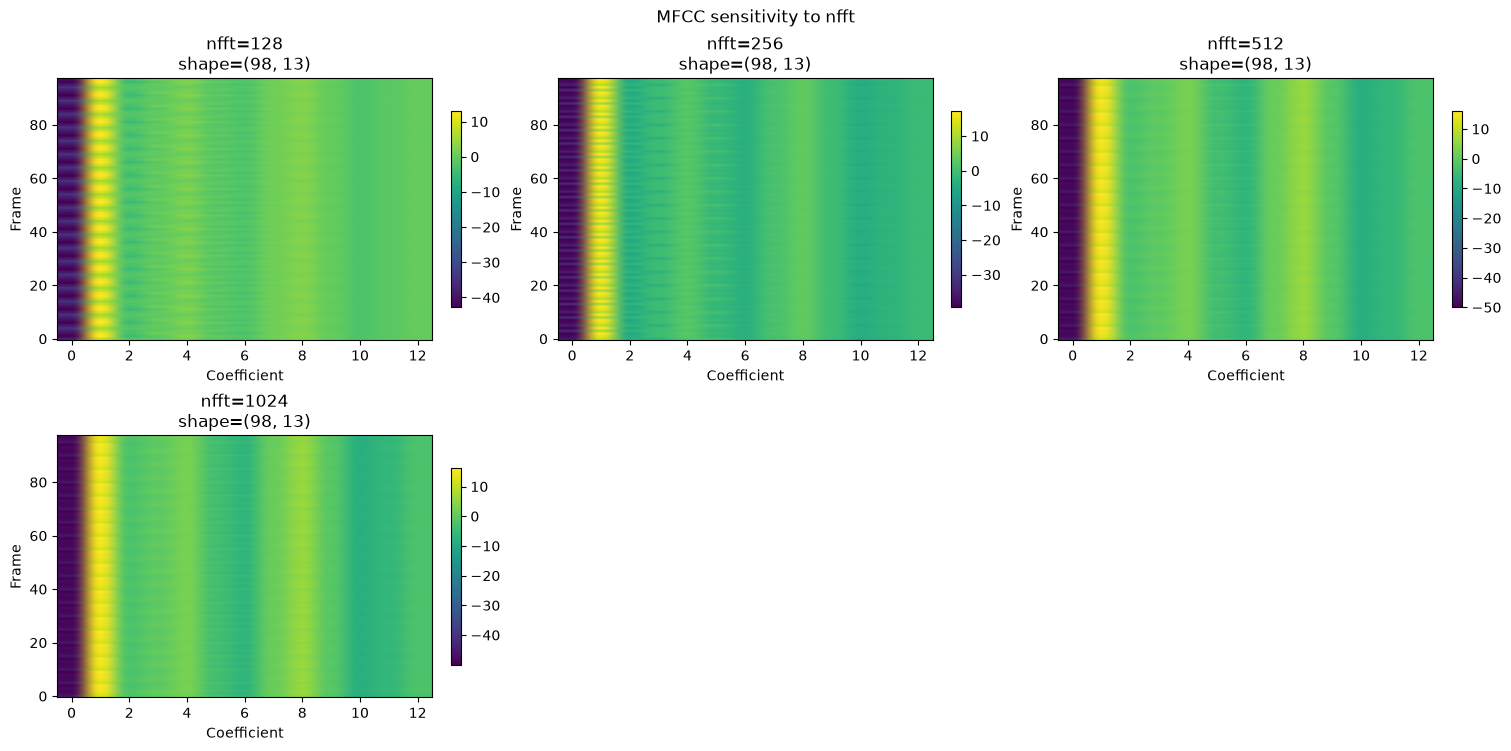

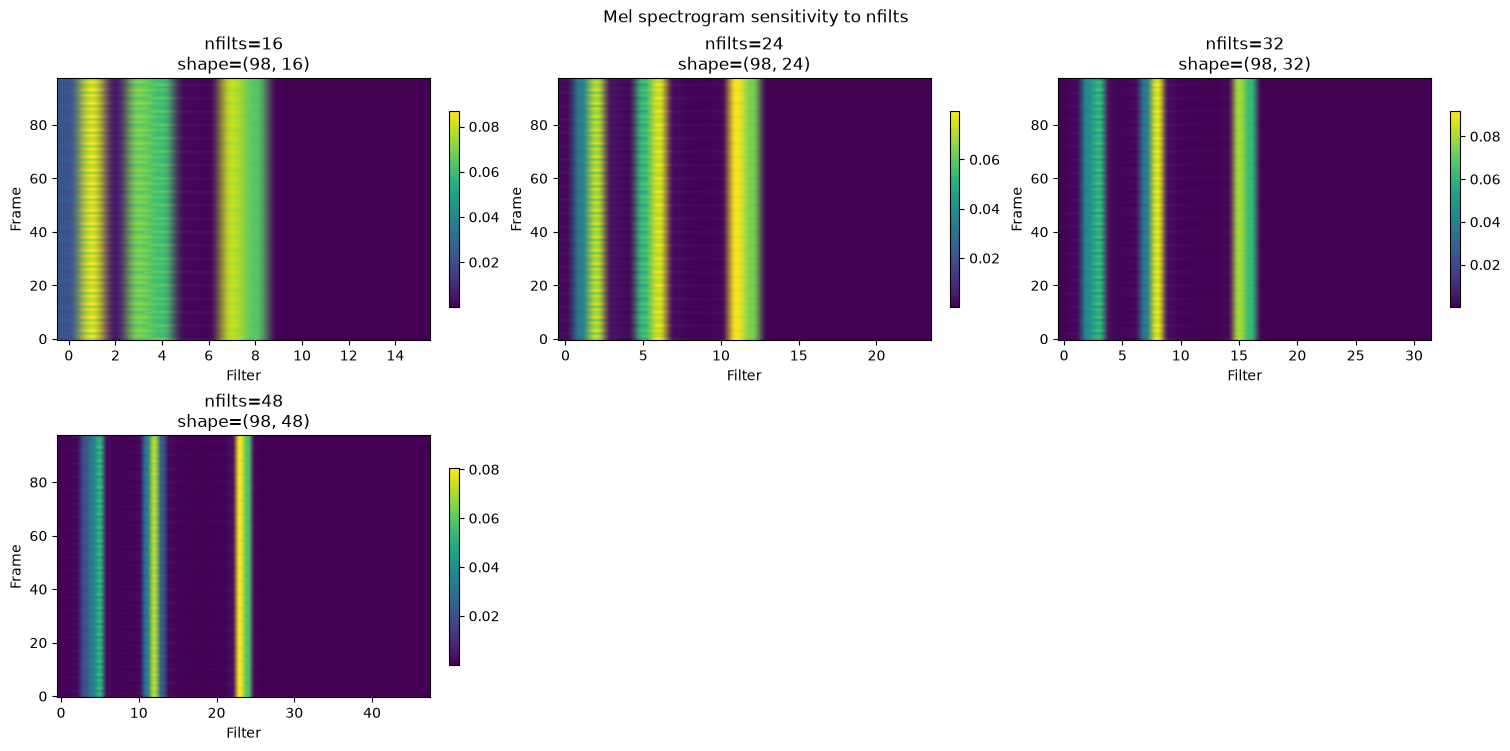

In [4]:
nfft_cases = []
for nfft in [128, 256, 512, 1024]:
    local_opts = opts(nfft=nfft)
    nfft_cases.append((f"nfft={nfft}", spafe.mfcc(signal, local_opts)))
plot_feature_grid(nfft_cases, "MFCC sensitivity to nfft")

nfilts_cases = []
for nfilts in [16, 24, 32, 48]:
    local_opts = opts(nfilts=nfilts)
    nfilts_cases.append((f"nfilts={nfilts}", spafe.mel_spectrogram(signal, local_opts).features))
plot_feature_grid(nfilts_cases, "Mel spectrogram sensitivity to nfilts", xlabel="Filter")

## Window Length and Hop

Window length changes the amount of audio per frame; hop length controls frame density. Smaller hops produce more rows.

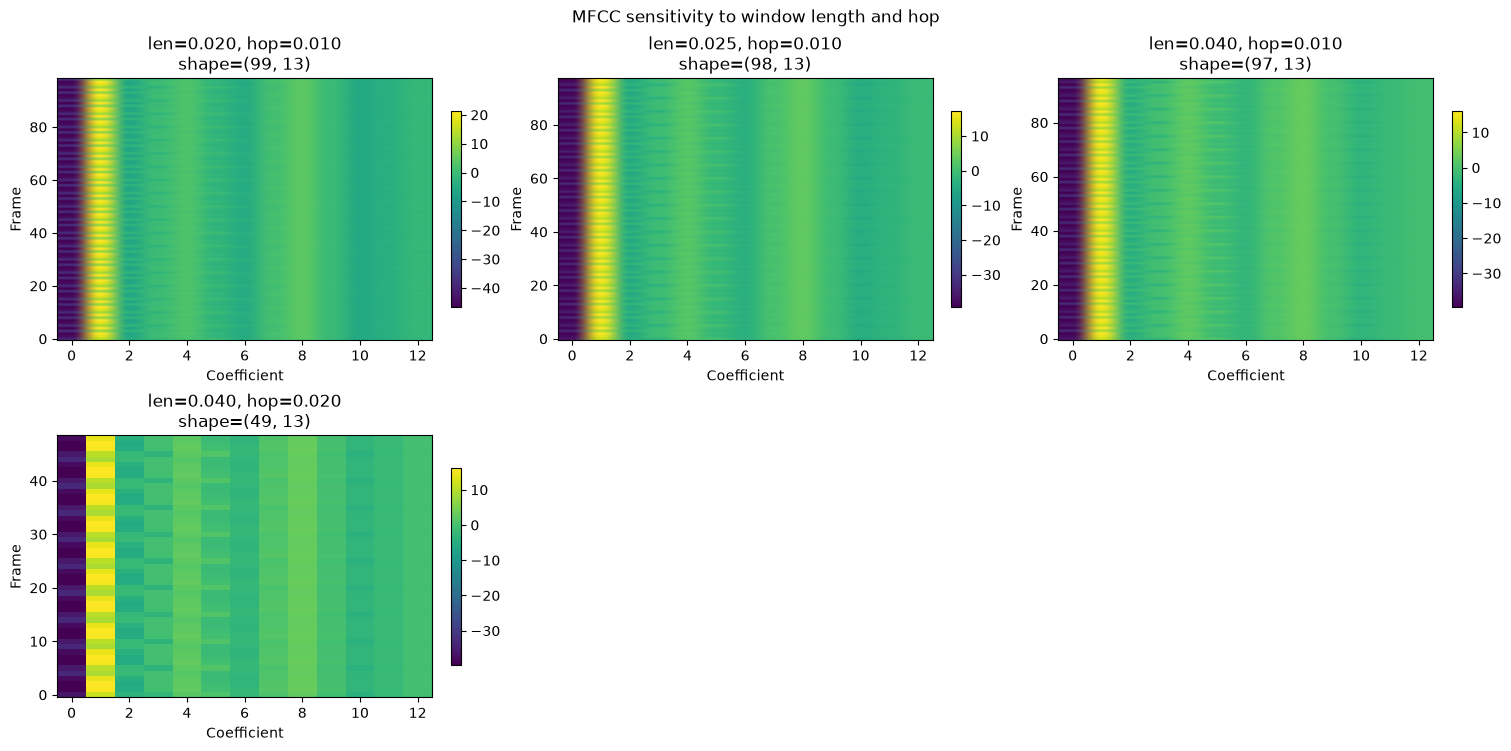

In [5]:
window_cases = []
for win_len, win_hop in [(0.020, 0.010), (0.025, 0.010), (0.040, 0.010), (0.040, 0.020)]:
    local_opts = opts(win_len=win_len, win_hop=win_hop)
    window_cases.append((f"len={win_len:.3f}, hop={win_hop:.3f}", spafe.mfcc(signal, local_opts)))
plot_feature_grid(window_cases, "MFCC sensitivity to window length and hop")

## Pre-emphasis, Energy, Normalization, and Liftering

These options alter cepstral values after or before the main spectral path. They are often tuned for downstream models rather than inspected alone.

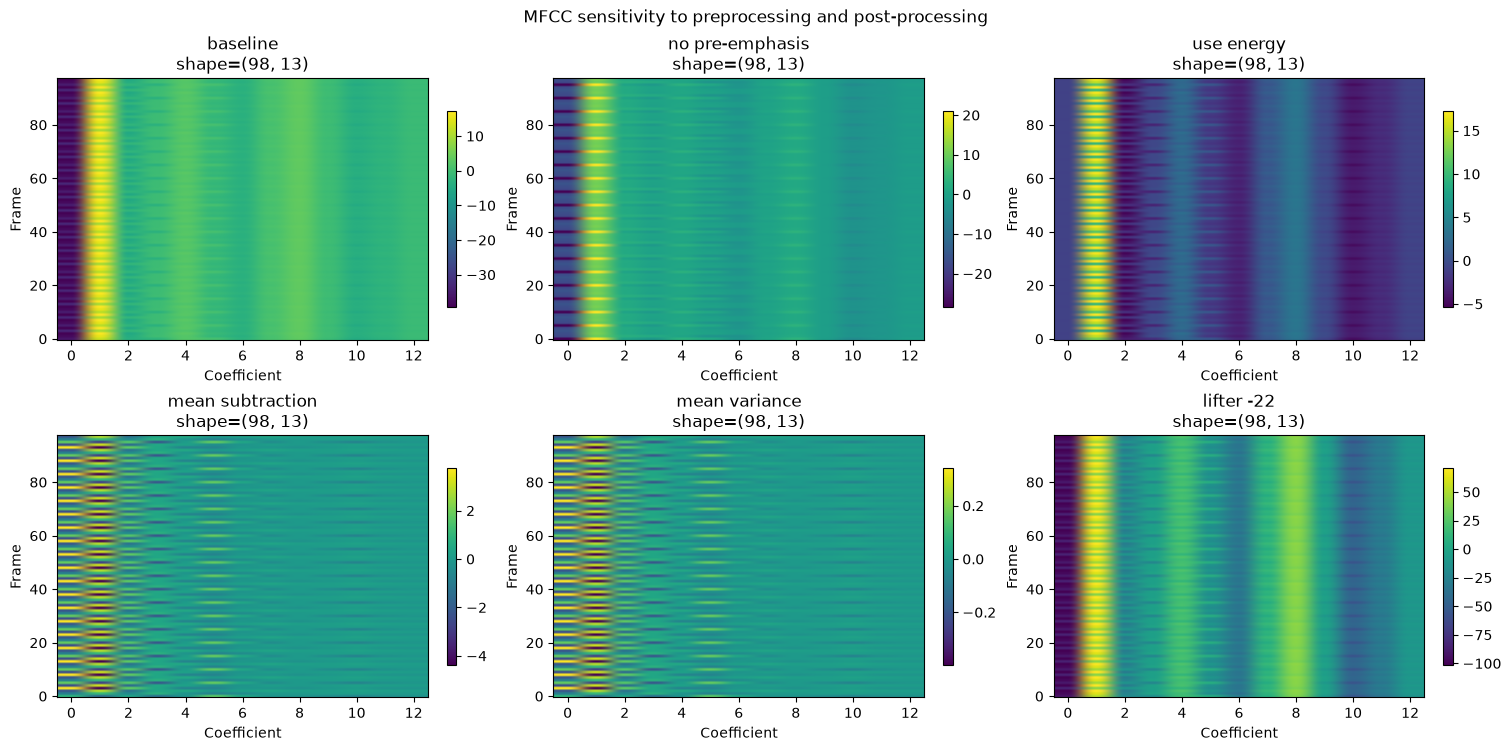

In [6]:
post_cases = [
    ("baseline", spafe.mfcc(signal, opts())),
    ("no pre-emphasis", spafe.mfcc(signal, opts(pre_emph=False))),
    ("use energy", spafe.mfcc(signal, opts(use_energy=True))),
    ("mean subtraction", spafe.mfcc(signal, opts(normalize="mean_subtraction"))),
    ("mean variance", spafe.mfcc(signal, opts(normalize="mean_variance"))),
    ("lifter -22", spafe.mfcc(signal, opts(lifter=-22))),
]
plot_feature_grid(post_cases, "MFCC sensitivity to preprocessing and post-processing")

## Window Type

The crate supports Hamming, Hanning, Bartlett, Blackman, and Kaiser windows. Differences are subtle in cepstral space but can matter for leakage-sensitive workflows.

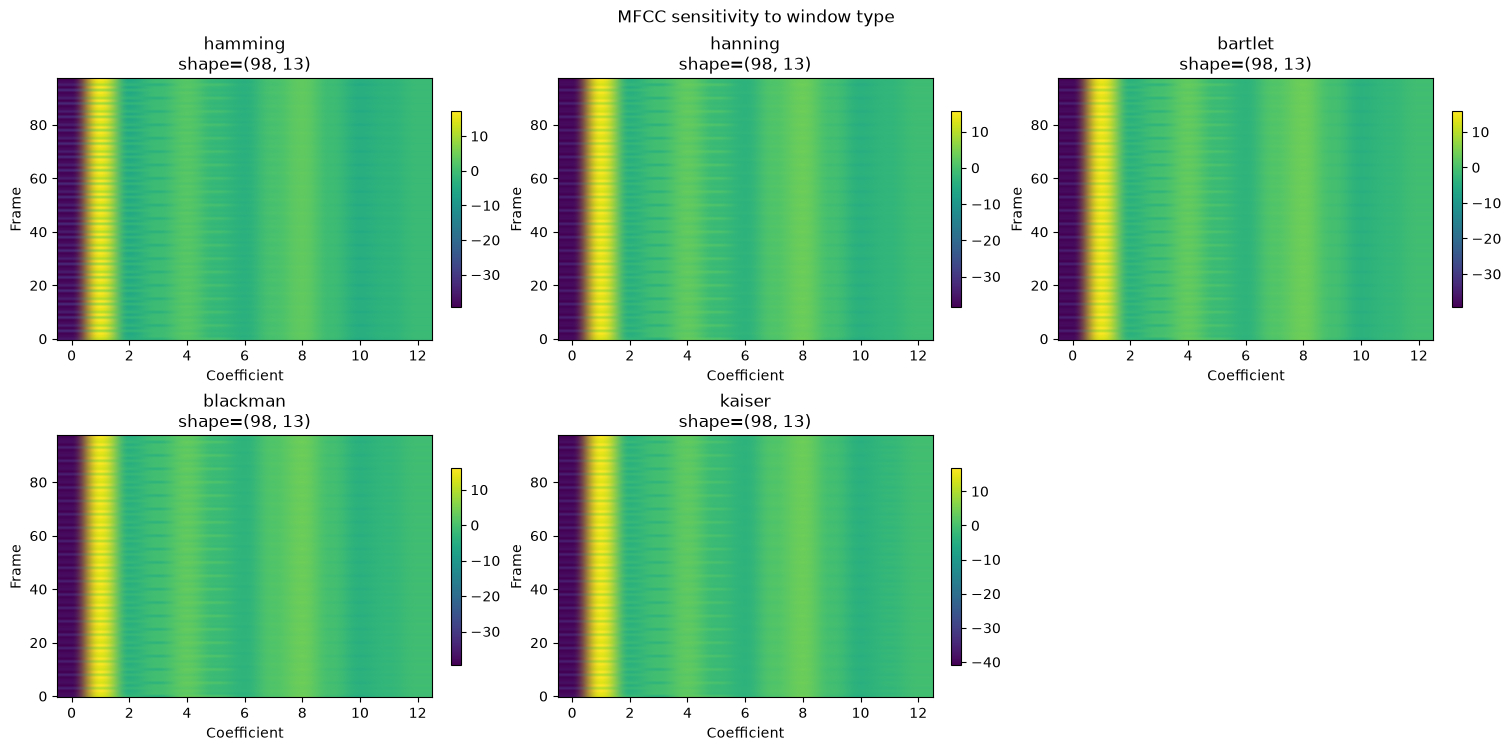

In [7]:
window_type_cases = []
for win_type in ["hamming", "hanning", "bartlet", "blackman", "kaiser"]:
    window_type_cases.append((win_type, spafe.mfcc(signal, opts(win_type=win_type))))
plot_feature_grid(window_type_cases, "MFCC sensitivity to window type")

## Filter-Bank Scaling

Filter-bank scaling changes the relative emphasis of low and high filter rows.

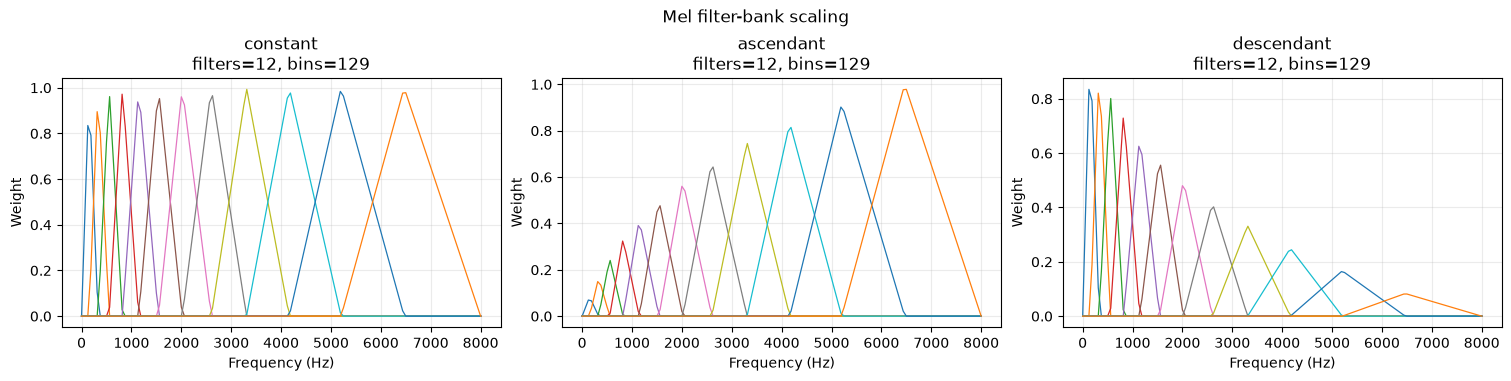

In [8]:
scale_cases = []
for scale in ["constant", "ascendant", "descendant"]:
    local = filter_opts(scale=scale, nfilts=12, nfft=256)
    bank, _ = spafe.mel_filter_banks(local)
    freqs = [idx * local.fs / local.nfft for idx in range(local.nfft // 2 + 1)]
    scale_cases.append((scale, bank, freqs))
plot_filter_grid(scale_cases, "Mel filter-bank scaling")

## High/Low Frequency Bounds

Bounds restrict filter-bank coverage. This is useful when focusing on speech bands or excluding low-frequency rumble.

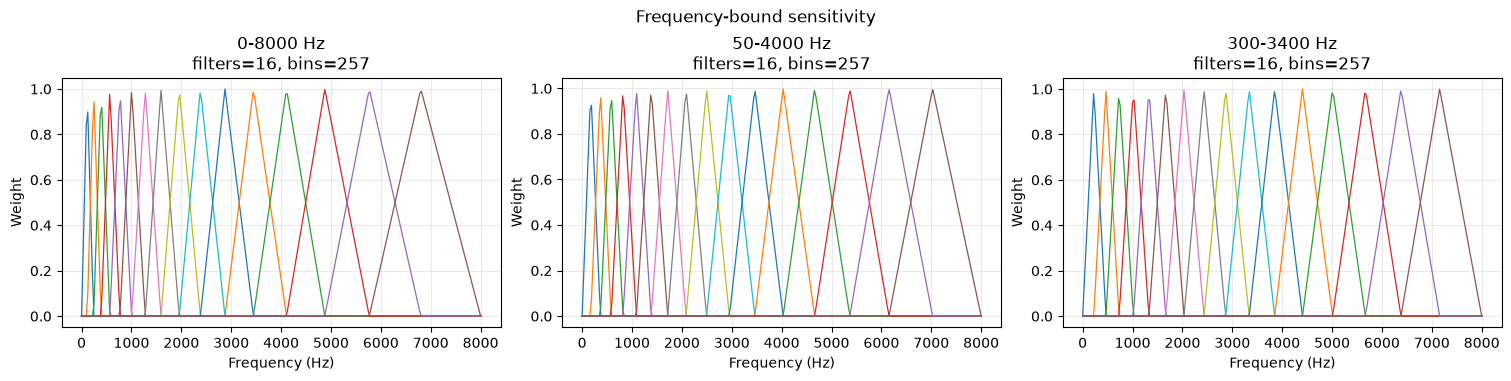

In [9]:
bound_cases = []
for low, high in [(0.0, 8000.0), (50.0, 4000.0), (300.0, 3400.0)]:
    local = filter_opts(low_freq=low, high_freq=high, nfilts=16, nfft=512)
    bank, _ = spafe.mel_filter_banks(local)
    freqs = [idx * local.fs / local.nfft for idx in range(local.nfft // 2 + 1)]
    bound_cases.append((f"{low:.0f}-{high:.0f} Hz", bank, freqs))
plot_filter_grid(bound_cases, "Frequency-bound sensitivity")

## Quick Numeric Summary

A small table helps quantify the effect of each option set beyond visual inspection.

In [10]:
summary_cases = {
    "baseline": spafe.mfcc(signal, opts()),
    "no_pre": spafe.mfcc(signal, opts(pre_emph=False)),
    "energy": spafe.mfcc(signal, opts(use_energy=True)),
    "mean_var": spafe.mfcc(signal, opts(normalize="mean_variance")),
    "lifter": spafe.mfcc(signal, opts(lifter=-22)),
}
print(f"{'case':12s} {'mean':>12s} {'std':>12s} {'min':>12s} {'max':>12s}")
print("-" * 64)
for name, matrix in summary_cases.items():
    arr = np.asarray(matrix)
    print(f"{name:12s} {arr.mean():12.4f} {arr.std():12.4f} {arr.min():12.4f} {arr.max():12.4f}")

case                 mean          std          min          max
----------------------------------------------------------------
baseline          -2.5763      11.0040     -39.4338      17.2938
no_pre            -0.9555       6.7802     -28.5209      21.0903
energy             0.1986       4.6783      -5.3983      17.2938
mean_var           0.0000       0.1101      -0.3969       0.3413
lifter           -10.4474      37.8147    -101.1659      70.8883


## Practical Notes

- Tune `win_len` and `win_hop` based on the temporal resolution your task needs.
- Increase `nfft` for finer frequency resolution, but expect more work per frame.
- `nfilts` changes filter-bank detail; `num_ceps` controls how many DCT coefficients you keep.
- Normalization and liftering can dominate the visual scale, so compare with fixed color limits when doing careful analysis.
- Frequency bounds should match the domain: speech, music, bioacoustics, or narrow-band sensors may need different ranges.